Imports

In [22]:
import numpy as np
import pandas as pd
import matplotlib as plt
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
import joblib

Read Data

In [23]:
irrigation = pd.read_csv("../data/train.csv")

In [ ]:
pd.set_option("display.max_columns", None)
irrigation.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [25]:
irrigation.shape

(630000, 21)

In [26]:
irrigation.columns.to_list()

['id',
 'Soil_Type',
 'Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Field_Area_hectare',
 'Mulching_Used',
 'Previous_Irrigation_mm',
 'Region',
 'Irrigation_Need']

In [27]:
irrigation["Irrigation_Need"].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [28]:
targets = ["Low", "Medium", "High"]
percent = []

for target in targets:
    df = irrigation[irrigation["Irrigation_Need"] == target]
    count = len(df)
    overall = len(irrigation)
    dfcount = round((count/overall)*100, 2)

    percent.append({target : dfcount})
print (percent)
    
    

[{'Low': 58.72}, {'Medium': 37.95}, {'High': 3.33}]


In [29]:
irrigation.sample(20)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
582049,582049,Clay,7.45,11.12,1.26,3.13,18.05,84.63,995.13,10.09,15.63,Rice,Harvest,Kharif,Sprinkler,River,3.63,Yes,66.07,West,Low
476584,476584,Loamy,6.42,54.49,0.52,0.76,32.02,91.96,2016.77,10.39,18.09,Wheat,Flowering,Rabi,Drip,River,10.10,No,49.35,Central,Medium
339255,339255,Sandy,7.72,40.27,1.10,0.16,12.75,89.02,2164.70,4.74,15.43,Wheat,Sowing,Rabi,Canal,River,14.05,Yes,90.39,Central,Low
528129,528129,Loamy,5.05,46.27,1.41,3.44,13.19,69.83,796.95,4.31,7.62,Cotton,Sowing,Zaid,Canal,Groundwater,5.74,Yes,42.32,East,Low
178984,178984,Loamy,5.26,54.29,0.72,2.98,13.77,82.79,1579.36,7.44,15.21,Potato,Vegetative,Kharif,Rainfed,Rainwater,12.59,No,65.39,Central,Medium
575990,575990,Silt,7.97,17.09,1.06,3.01,24.11,62.19,1034.95,10.57,8.21,Sugarcane,Vegetative,Kharif,Canal,Groundwater,3.80,No,94.31,South,Medium
400641,400641,Loamy,5.41,34.13,0.38,2.12,36.50,71.62,2479.97,7.08,1.52,Potato,Harvest,Rabi,Canal,Rainwater,9.79,Yes,26.49,Central,Low
234868,234868,Loamy,6.82,54.10,0.38,2.85,36.18,37.06,2140.75,5.67,1.95,Potato,Sowing,Zaid,Drip,Reservoir,3.92,No,40.89,West,Low
304391,304391,Silt,7.09,49.66,0.42,0.73,31.85,36.33,1403.09,9.09,15.35,Sugarcane,Sowing,Kharif,Sprinkler,Groundwater,2.71,No,6.66,North,Low
150699,150699,Sandy,7.98,59.32,0.57,1.43,36.10,81.58,868.58,4.59,10.81,Cotton,Flowering,Kharif,Sprinkler,Rainwater,10.69,No,35.07,South,Medium


Split Data

In [30]:
irrigation["Irrigation_Need"].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [31]:
irrigation["Irrigation_Need"].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [32]:
irrigation.isna().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [33]:
irrigation["Irrigation_Need"].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [34]:
irrigation.dtypes

id                           int64
Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

In [35]:
X = irrigation.drop(columns = ["Irrigation_Need", "id"])
y = irrigation["Irrigation_Need"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [37]:
categorical_columns = X.select_dtypes("object").columns.tolist()

In [38]:
categorical_columns

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

In [39]:
numerical_columns = X.select_dtypes(exclude=['object']).columns.tolist()

In [40]:
numerical_columns

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [41]:
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    eval_metric='logloss',
)

# model = LogisticRegression(random_state=42)

In [42]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [43]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [44]:
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

In [45]:
predictions = model_pipeline.predict(X_test)

In [46]:
probabilities = model_pipeline.predict_proba(X_test)

In [47]:
probabilities

array([[4.9613271e-05, 9.9905807e-01, 8.9228852e-04],
       [3.2803200e-02, 2.2529601e-03, 9.6494383e-01],
       [2.4725532e-04, 1.3956577e-03, 9.9835712e-01],
       ...,
       [1.4604985e-02, 1.1779518e-03, 9.8421705e-01],
       [5.5524895e-05, 9.9877173e-01, 1.1727194e-03],
       [7.7093202e-05, 9.9897987e-01, 9.4299560e-04]],
      shape=(126000, 3), dtype=float32)

In [48]:
model.classes_

array([0, 1, 2])

In [49]:
report = classification_report(y_test, predictions)
accuracy = accuracy_score(y_test, predictions)
print(report)
print(accuracy)

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      4202
           1       0.99      0.99      0.99     73983
           2       0.98      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

0.9850714285714286


In [50]:
cm = confusion_matrix(y_test, predictions)

In [51]:
cm

array([[ 3871,     0,   331],
       [    0, 73586,   397],
       [  158,   995, 46662]])

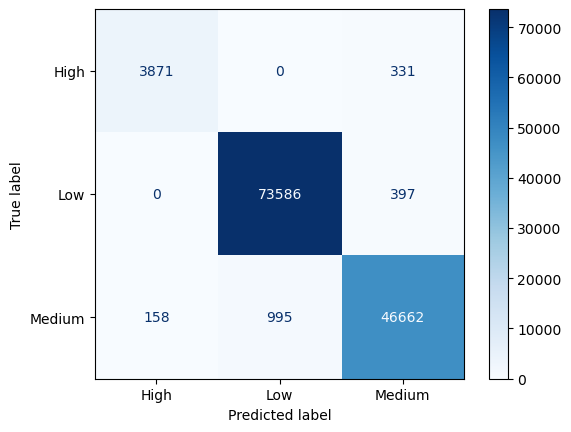

In [52]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["High", "Low", "Medium"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [59]:
joblib.dump(model_pipeline, "../models/model.pkl")

['../models/model.pkl']

In [63]:
numerical_columns

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [64]:
categorical_columns

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

In [58]:
for col in categorical_columns:
    df_counts = irrigation[col].value_counts().reset_index()
    df_counts.columns = [col, "Count"]
    
    print(f"\n--- {col} ---")
    print(df_counts)


--- Soil_Type ---
  Soil_Type   Count
0     Sandy  166509
1      Clay  158470
2     Loamy  156455
3      Silt  148566

--- Crop_Type ---
   Crop_Type   Count
0  Sugarcane  108910
1       Rice  106697
2     Cotton  104645
3      Maize  104274
4      Wheat  103005
5     Potato  102469

--- Crop_Growth_Stage ---
  Crop_Growth_Stage   Count
0           Harvest  167689
1         Flowering  157563
2        Vegetative  157246
3            Sowing  147502

--- Season ---
   Season   Count
0  Kharif  216561
1    Rabi  208033
2    Zaid  205406

--- Irrigation_Type ---
  Irrigation_Type   Count
0           Canal  161901
1       Sprinkler  161400
2         Rainfed  155607
3            Drip  151092

--- Water_Source ---
  Water_Source   Count
0    Reservoir  162994
1        River  159819
2  Groundwater  154155
3    Rainwater  153032

--- Mulching_Used ---
  Mulching_Used   Count
0            No  316453
1           Yes  313547

--- Region ---
    Region   Count
0    South  134809
1     West  131189
